In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import sys
sys.path.append('./')
sys.path.append('/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival/')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import torch
from tqdm import tqdm 
from examples.cmhe_demo_utils import * 
from metrics import treatment_effect

c:\Users\ASUS\anaconda3\envs\Pandas\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [34]:
# Load dataset
from datasets_retrospective import load_accord_dataset
outcomes, features, intervention, cat_feats, num_feats = load_accord_dataset(location='datasets/ACCORD/', outcome='', intervention='Lipid')

No Features Specified!! using default baseline features.
(10251, 5)
(10205, 3)
(10251, 21)
(10197, 5)
(10240, 9)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:741: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outcomes['event'] = 1-outcomes['event']
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_re

In [3]:
# intervention = intervention.dropna()
# features = features.loc[intervention.dropna().index]
# outcomes = outcomes.loc[intervention.dropna().index]

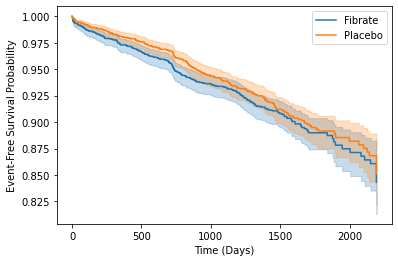

In [35]:
from auton_survival import reporting
import matplotlib.pyplot as plt
axx = reporting.plot_kaplanmeier(outcomes, intervention)
h, l = axx.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Fibrate', 'Placebo'], loc="upper right")
plt.show()
pass

In [37]:
# Preprocess feature data
from preprocessing import Preprocessor
features_prep = Preprocessor().fit_transform(data=features[cat_feats+num_feats], cat_feats=cat_feats, num_feats=num_feats)

In [39]:
# # Hyper-parameters
# random_seed = 0
# test_size = 0.4

# # Split the synthetic data into training and testing data
# import numpy as np

# np.random.seed(random_seed)
# n = features.shape[0] 

# test_idx = np.zeros(n).astype('bool')
# test_idx[np.random.randint(n, size=int(n*test_size))] = True 

# features_tr = features_prep.iloc[~test_idx] 
# outcomes_tr = outcomes.iloc[~test_idx]
# interventions_tr = intervention[~test_idx]
# print(f'Number of training data points: {len(features_tr)}')

# features_te = features_prep.iloc[test_idx] 
# outcomes_te = outcomes.iloc[test_idx]
# interventions_te = intervention[test_idx]
# print(f'Number of test data points: {len(features_te)}')

# x_tr = features_tr.values.astype('float32')
# t_tr = outcomes_tr['time'].values.astype('float32')
# e_tr = outcomes_tr['event'].values.astype('float32')
# a_tr = (interventions_tr == 'Lipid Fibrate').values.astype('float32')

# x_te = features_te.values.astype('float32')
# t_te = outcomes_te['time'].values.astype('float32')
# e_te = outcomes_te['event'].values.astype('float32')
# a_te = (interventions_te == 'Lipid Fibrate').values.astype('float32')

# print('Training Data Statistics:')
# print(f'Shape of covariates: {x_tr.shape} | times: {t_tr.shape} | events: {e_tr.shape} | interventions: {a_tr.shape}')

Number of training data points: 3548
Number of test data points: 1730
Training Data Statistics:
Shape of covariates: (3548, 43) | times: (3548,) | events: (3548,) | interventions: (3548,)


In [51]:
# Hyper-parameters to train CMHE model
k = 1 # number of underlying base survival phenotypes
g = 2 # number of underlying treatment effect phenotypes.
layers = [] # number of neurons in each hidden layer.
random_seed = 3
iters = 100 # number of training epochs
learning_rate = 0.001
batch_size = 256 
patience = 5
optimizer = "Adam"
gate_l2_penalty = 1e-3

In [52]:
from models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model on all data
model = DeepCoxMixturesHeterogenousEffects(random_seed=10, k=k, g=g, layers=layers, gate_l2_penalty=gate_l2_penalty)

model = model.fit(features_prep, outcomes.time, outcomes.event, intervention=='Lipid Fibrate', val_data=None, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

100%|██████████| 100/100 [00:21<00:00,  4.69it/s]


In [53]:
zeta_probs = model.predict_latent_phi(features_prep)
zeta = np.argmax(zeta_probs, axis=1)

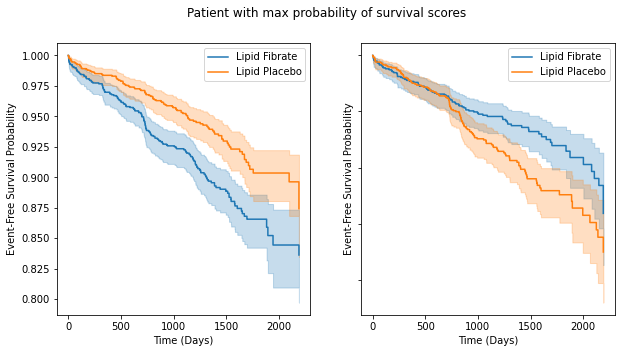

In [54]:
from auton_survival import reporting
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Patient with max probability of survival scores')
reporting.plot_kaplanmeier(outcomes[zeta == 0], intervention[zeta == 0], ax=ax1)
reporting.plot_kaplanmeier(outcomes[zeta == 1], intervention[zeta == 1], ax=ax2)
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Lipid Fibrate', 'Lipid Placebo'], loc="upper right")
plt.show()

In [42]:
from models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model
model = DeepCoxMixturesHeterogenousEffects(random_seed=7, k=k, g=g, layers=layers)

model = model.fit(x_tr, t_tr, e_tr, a_tr, vsize=vsize, val_data=None, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

 33%|███▎      | 33/100 [00:08<00:16,  4.03it/s]


In [43]:
zeta_probs_train = model.predict_latent_phi(x_tr)
zeta_train =  np.argmax(zeta_probs_train, axis=1)
zeta_train

array([1, 0, 0, ..., 1, 0, 0], dtype=int64)

In [44]:
zeta_train.mean()

0.3666854565952649

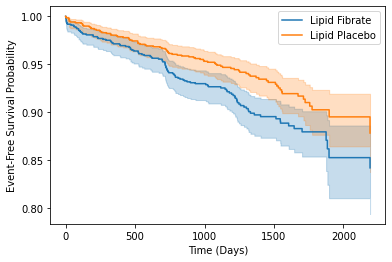

In [45]:
from auton_survival import reporting
import matplotlib.pyplot as plt

# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax = reporting.plot_kaplanmeier(outcomes_tr[zeta_train == 0], interventions_tr[zeta_train == 0])
h, l = ax.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Lipid Fibrate', 'Lipid Placebo'], loc="upper right")
plt.show()

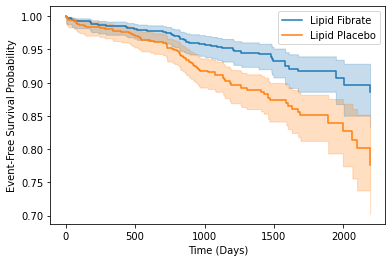

In [46]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax2 = reporting.plot_kaplanmeier(outcomes_tr[zeta_train == 1], interventions_tr[zeta_train == 1])
h, l = ax2.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Lipid Fibrate', 'Lipid Placebo'], loc="upper right")
plt.show()

In [47]:
zeta_probs_test = model.predict_latent_phi(x_te)
zeta_test =  np.argmax(zeta_probs_test, axis=1)
zeta_test

array([1, 0, 0, ..., 0, 1, 1], dtype=int64)

In [48]:
zeta_test.mean()

0.3578034682080925

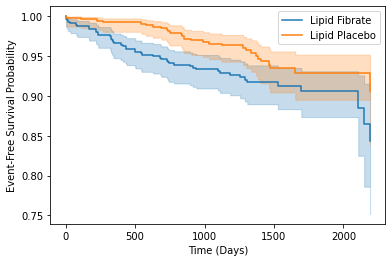

In [49]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax3 = reporting.plot_kaplanmeier(outcomes_te[zeta_test == 0], interventions_te[zeta_test == 0])
h, l = ax3.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Lipid Fibrate', 'Lipid Placebo'], loc="upper right")
plt.show()

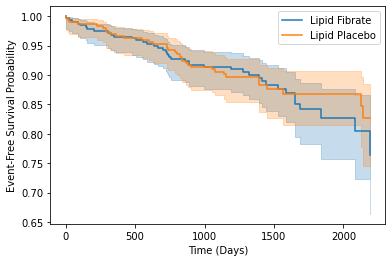

In [50]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax4 = reporting.plot_kaplanmeier(outcomes_te[zeta_test == 1], interventions_te[zeta_test == 1])
h, l = ax4.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Lipid Fibrate', 'Lipid Placebo'], loc="upper right")
plt.show()